# K-Medoid

In [1]:
import warnings
warnings.filterwarnings('ignore')

Medoids Akhir: [array([14,  6]), array([6, 8]), array([5, 5])]
Cluster 1: [array([10,  2]), array([12,  3]), array([11,  5]), array([13,  5]), array([14,  6]), array([15,  5]), array([12,  7]), array([14,  8]), array([16,  6]), array([15,  9])]
Cluster 2: [array([3, 8]), array([5, 8]), array([8, 7]), array([6, 8]), array([7, 9])]
Cluster 3: [array([2, 6]), array([3, 4]), array([7, 5]), array([6, 4]), array([5, 5])]


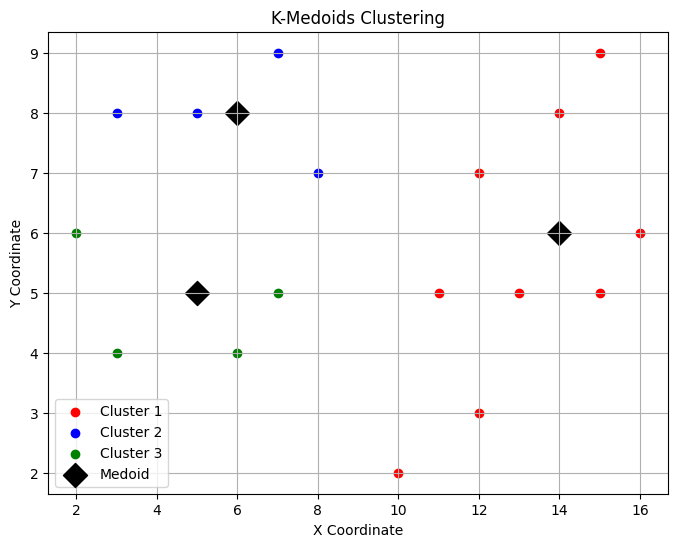

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def euclidean_distance(p1, p2):
    """Menghitung jarak Euclidean antara dua titik."""
    return np.sqrt(np.sum((np.array(p1)-np.array(p2))**2))
def total_cost(cluster, medoid):
    """Menghitung total jarak dari semua titik dalam kluster ke medoid."""
    return sum(euclidean_distance(point, medoid) for point in cluster)
def assign_clusters(data, medoids):
    clusters = {i: [] for i in range(len(medoids))}
    for point in data:
        distances = [euclidean_distance(point, medoid) for medoid in medoids]
        closest_medoid = np.argmin(distances)
        clusters[closest_medoid].append(point)
    return clusters

def k_medoids(data, k, max_iter=100):
    """Implementasi K-Medoids dari nol."""
    # Inisialisasi: Pilih K medoid secara acak
    medoid_indices = np.random.choice(len(data), k, replace=False)
    medoids = [data[i] for i in medoid_indices]

    for _ in range(max_iter):
        clusters = assign_clusters(data, medoids)
        new_medoids = []
        for cluster_idx in clusters:
            cluster_points = clusters[cluster_idx]
            best_medoid = medoids[cluster_idx]
            best_cost = total_cost(cluster_points, best_medoid)

            # Coba setiap titik dalam kluster sebagai kandidat medoid baru
            for candidate in cluster_points:
                cost = total_cost(cluster_points, candidate)
                if cost < best_cost:
                    best_cost = cost
                    best_medoid = candidate
            new_medoids.append(best_medoid)

        # Jika medoid tidak berubah, hentikan iterasi
        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids

    return medoids, assign_clusters(data, medoids)

def plot_clusters(data, medoids, clusters):
    """Visualisasi hasil clustering K-Medoids."""
    colors = ['r', 'b', 'g', 'c', 'm', 'y', 'k']  # Warna kluster (maks 7)
    plt.figure(figsize=(8, 6))
    for cluster_idx, points in clusters.items():
        points = np.array(points)
        plt.scatter(points[:, 0], points[:, 1], color=colors[cluster_idx], label=f'Cluster {cluster_idx+1}')
    
    # Plot medoid dengan simbol berbeda
    medoids = np.array(medoids)
    plt.scatter(medoids[:, 0], medoids[:, 1], color='black', marker='D', s=150, label='Medoid')

    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.title('K-Medoids Clustering')
    plt.legend()
    plt.grid()
    plt.show()

# Contoh Data (20 titik dengan 3 kluster)
data = np.array([
    [2, 6], [3, 4], [3, 8], [5, 8], [7, 5], [6, 4], [8, 7], [5, 5], [6, 8], [7, 9],
    [10, 2], [12, 3], [11, 5], [13, 5], [14, 6], [15, 5], [12, 7], [14, 8], [16, 6], [15, 9]
])

# Jalankan K-Medoids dengan K = 3
k = 3
final_medoids, final_clusters = k_medoids(data, k)

# Tampilkan hasil klasterisasi
print("Medoids Akhir:", final_medoids)
for i, cluster in final_clusters.items():
    print(f"Cluster {i+1}: {cluster}")

# Plot klaster
plot_clusters(data, final_medoids, final_clusters)

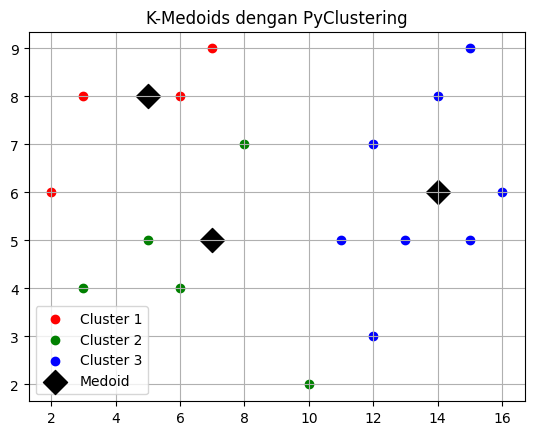

In [3]:
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix
import matplotlib.pyplot as plt
import numpy as np

# Data
data = np.array([
    [2, 6], [3, 4], [3, 8], [5, 8], [7, 5], [6, 4], [8, 7], [5, 5], [6, 8], [7, 9],
    [10, 2], [12, 3], [11, 5], [13, 5], [14, 6], [15, 5], [12, 7], [14, 8], [16, 6], [15, 9]
])

initial_medoids = [1, 5, 10]

# Jalankan K-Medoids
kmedoids_instance = kmedoids(data, initial_medoids)
kmedoids_instance.process()

# Ambil hasil
clusters = kmedoids_instance.get_clusters()
final_medoids = kmedoids_instance.get_medoids()

# Visualisasi
colors = ['r', 'g', 'b']
for i, cluster in enumerate(clusters):
    cluster_points = np.array([data[j] for j in cluster])
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f"Cluster {i+1}")

medoid_points = np.array([data[i] for i in final_medoids])
plt.scatter(medoid_points[:, 0], medoid_points[:, 1], marker='D', s=150, color='black', label='Medoid')
plt.legend()
plt.title("K-Medoids dengan PyClustering")
plt.grid()
plt.show()
